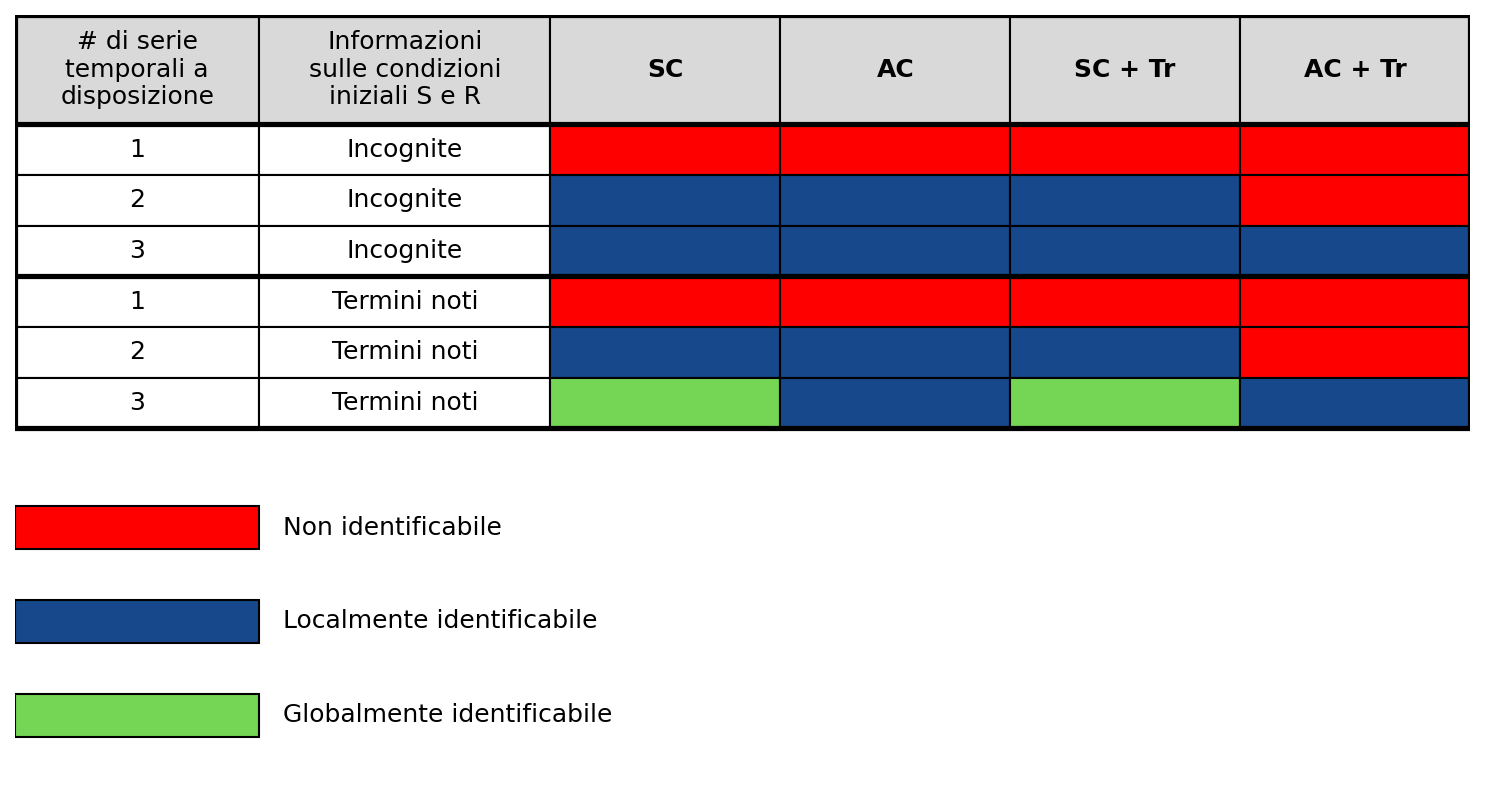

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Creazione della figura
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Impostazioni dei limiti per mantenere le proporzioni
ax.set_xlim(0, 12.5)
ax.set_ylim(10, 0) # Asse Y invertito per disegnare dall'alto verso il basso
ax.axis('off') # Rimuove gli assi

# Definizione dei colori estratti dall'immagine
color_red = '#FF0000'
color_blue = '#16488B'
color_green = '#75D554'
color_gray = '#D9D9D9'
color_white = '#FFFFFF'

# Coordinate X per le colonne
cols = [0, 2.1, 4.6, 6.575, 8.55, 10.525, 12.5] 

# Coordinate Y per le righe (altezza righe)
rows = [0, 1.4, 2.05, 2.7, 3.35, 4.0, 4.65, 5.3]

# Funzione di supporto per disegnare le celle
def draw_cell(x, y, w, h, bg_color, text='', weight='normal', size=11):
    rect = patches.Rectangle((x, y), w, h, facecolor=bg_color, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    if text:
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', weight=weight, fontsize=size, color='black')

# 1. Disegna le intestazioni (Header)
headers = [
    ("# di serie\ntemporali a\ndisposizione", 'normal'),
    ("Informazioni\nsulle condizioni\niniziali S e R", 'normal'),
    ("SC", 'bold'),
    ("AC", 'bold'),
    ("SC + Tr", 'bold'),
    ("AC + Tr", 'bold')
]
for i in range(6):
    draw_cell(cols[i], rows[0], cols[i+1]-cols[i], rows[1]-rows[0], color_gray, headers[i][0], headers[i][1], 12)

# 2. Disegna i dati (Righe)
data = [
    ("1", "Incognite", [color_red, color_red, color_red, color_red]),
    ("2", "Incognite", [color_blue, color_blue, color_blue, color_red]),
    ("3", "Incognite", [color_blue, color_blue, color_blue, color_blue]),
    ("1", "Termini noti", [color_red, color_red, color_red, color_red]),
    ("2", "Termini noti", [color_blue, color_blue, color_blue, color_red]),
    ("3", "Termini noti", [color_green, color_blue, color_green, color_blue])
]

for r_idx, row_data in enumerate(data):
    y = rows[r_idx+1]
    h = rows[r_idx+2] - rows[r_idx+1]
    
    # Colonne 1 e 2 (Testo)
    draw_cell(cols[0], y, cols[1]-cols[0], h, color_white, row_data[0], size=12)
    draw_cell(cols[1], y, cols[2]-cols[1], h, color_white, row_data[1], size=12)
    
    # Colonne 3 - 6 (Celle colorate)
    for c_idx, bg_color in enumerate(row_data[2]):
        draw_cell(cols[c_idx+2], y, cols[c_idx+3]-cols[c_idx+2], h, bg_color)

# 3. Aggiunge i bordi più spessi
thick_lw = 2.5
# Bordo esterno della tabella
ax.add_patch(patches.Rectangle((cols[0], rows[0]), cols[-1]-cols[0], rows[-1]-rows[0], 
                               fill=False, edgecolor='black', linewidth=thick_lw))
# Linea di divisione sotto l'intestazione
ax.plot([cols[0], cols[-1]], [rows[1], rows[1]], color='black', lw=thick_lw, solid_capstyle='butt')
# Linea di divisione tra la riga 3 e la riga 4
ax.plot([cols[0], cols[-1]], [rows[4], rows[4]], color='black', lw=thick_lw, solid_capstyle='butt')


# 4. Disegna la legenda in basso
legend_y_start = 6.3
legend_spacing = 1.2
legend_h = 0.55
legend_w = 2.1 # Larga quanto la prima colonna per mantenere allineamento

legends = [
    (color_red, "Non identificabile"),
    (color_blue, "Localmente identificabile"),
    (color_green, "Globalmente identificabile")
]

for i, (col, text) in enumerate(legends):
    y = legend_y_start + i*legend_spacing
    rect = patches.Rectangle((cols[0], y), legend_w, legend_h, facecolor=col, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    ax.text(cols[0] + legend_w + 0.2, y + legend_h/2, text, ha='left', va='center', fontsize=12)

plt.savefig('FIG6.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
# Mostra e formatta il grafico
plt.tight_layout()
plt.show()